In [12]:
## test1
from bigrams import BIGRAM_BAG

print(len(BIGRAM_BAG))
print(BIGRAM_BAG[:5])

40
['th', 'he', 'in', 'er', 'an']


In [13]:
## test2
from text_processing import count_tracked_bigrams, counts_to_vector

sentence = "The queen quickly quit the quiet quiz"
counts = count_tracked_bigrams(sentence)
print(counts)

vector = counts_to_vector(counts)
print(vector)

Counter({'th': 2, 'he': 2, 'en': 1, 'ic': 1, 'it': 1})
[2. 2. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]


In [14]:
## test 3
from typing_env import TypingEnv

env = TypingEnv()
env.reset()

for _ in range(5):
    state, reward, _, _ = env.step(0)
    print("Reward:", reward)

Reward: 0.11099904893351209
Reward: 0.04458122471224121
Reward: 0.10581023815337295
Reward: 0.06756805754268587
Reward: -0.0009471405484688944


In [15]:
## test 4
env.sample_sentence(0,1)

'gather the thick leather cloth and put it on the shelf'

### we can see the skill growing, as we ran 5 iterations, and rewards are positive.

In [16]:
## test 5
env = TypingEnv()
state = env.reset()

for _ in range(5):
    action = 0  # same bigram
    state, reward, _, _ = env.step(action)
    print("Reward:", reward)
    print("Skill:", env.k[0])

Reward: 0.04889702402993343
Skill: 0.35168216946795905
Reward: 0.08821626333579052
Skill: 0.4910777228989799
Reward: 0.04212420377996759
Skill: 0.5457897014447913
Reward: 0.03484549507562346
Skill: 0.5899823229329926
Reward: 0.0774510113853496
Skill: 0.6781406895852767


### Forgetting Curve

[np.float64(0.9999999999245704), np.float64(0.9999999999242687), np.float64(0.9999999999236628), np.float64(0.9999999999227468), np.float64(0.9999999999295429), np.float64(0.9999999999295429), np.float64(0.9999999999292611), np.float64(0.99999999993605), np.float64(0.99999999993605), np.float64(0.9999999999357942), np.float64(0.9999999999352805), np.float64(0.999999999934504), np.float64(0.999999999933456), np.float64(0.9999999999321252), np.float64(0.9999999999304962), np.float64(0.99999999992855), np.float64(0.9999999999262636), np.float64(0.9999999999236091), np.float64(0.9999999999205534), np.float64(0.9999999999170578), np.float64(0.9999999999130765), np.float64(0.9999999999085565), np.float64(0.9999999999034357), np.float64(0.9999999998976419), np.float64(0.999999999891091), np.float64(0.9999999998836852), np.float64(0.9999999998753105), np.float64(0.9999999998658341), np.float64(0.9999999998690503), np.float64(0.9999999998690503), np.float64(0.9999999998685265), np.float64(0.999

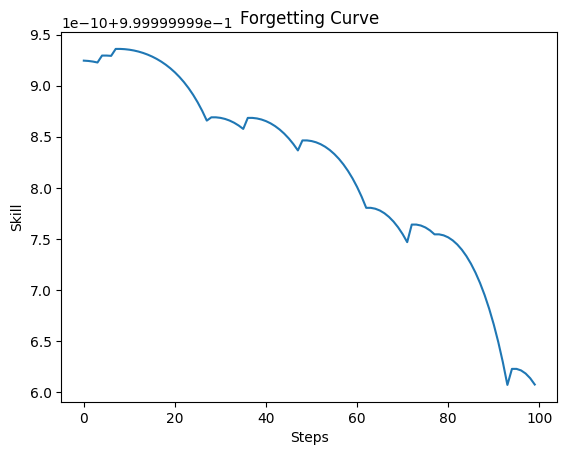

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from typing_env import TypingEnv


env = TypingEnv()
state = env.reset()

target_bigram = 39
difficulty = 3
action = target_bigram * env.L + difficulty

# forgetting curve experiment
env.reset()

learning_steps = 100
forget_steps = 100

forget_curve = []

# learn first
for step in range(learning_steps):
    state, reward, done, _ = env.step(action)

# stop practicing target bigram
for step in range(forget_steps):
    random_action = np.random.randint(0, env.K * env.L)
    state, reward, done, _ = env.step(31)
    forget_curve.append(env.k[target_bigram])

print(forget_curve)

plt.plot(forget_curve)
plt.title("Forgetting Curve")
plt.xlabel("Steps")
plt.ylabel("Skill")

plt.show()

In [87]:
import pandas as pd
df = pd.read_csv("typing_dataset.csv")
df.head()


,sentence,target_bigram,difficulty
0,the thin cat sat on the mat,th,0
1,this path has the moth on it,th,0
2,that cloth has both the moths,th,0
3,the bath with the thick cloth,th,0
4,both the teeth and the cloth,th,0


In [ ]:

for i in range(20):
    j = i // 20
    if(i==0):
        print(f"for bigram {BIGRAM_BAG[j]}")
    sentence = df['sentence'][i]
    print(count_tracked_bigrams(sentence)[BIGRAM_BAG[j]])
    

for bigram th
3
4
5
6
5
5
5
5
5
5
5
5
5
6
5
5
5
5
5
5
